# Exploratory Data Analysis — Decanter Wine Dataset

Initial exploration of ~10,000 wine reviews scraped from Decanter. Goals:
- Understand the shape and quality of the data
- Identify null values and decide how to handle them
- Analyse score, colour, country, and region distributions
- Check description lengths (key field for embeddings)
- Detect and inspect duplicate entries

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Data

In [3]:
df = pd.read_csv("../data/raw/wine_dataset.csv")
df.head()

,url,title,description,score,Producer,Brand,Vintage,Wine Type,Colour,Country,Region,Appellation,Sweetness,Closure,Alcohol,Body,Oak,Grapes
0,https://www.decanter.com/wine-reviews/italy/pi...,"Mauro Veglio, Barolo Arborina, La Morra, Piedm...","The estate’s first single-site bottling, in 19...",93.0,Mauro Veglio,NaN,2022.0,Still,Red,Italy,Piedmont,Barolo Arborina,Dry,Cork,14.50%,Full,Yes,100% Nebbiolo
1,https://www.decanter.com/wine-reviews/italy/pi...,"Fratelli Alessandria, Barolo Gramolere, Monfor...",Pristine fruit and a clear expression of place...,94.0,Fratelli Alessandria,NaN,2022.0,Still,Red,Italy,Piedmont,Barolo Gramolere,Dry,Cork,14.50%,Full,Oaked,100% Nebbiolo
2,https://www.decanter.com/wine-reviews/italy/pi...,"Ettore Germano, Barolo Vignarionda, Serralunga...",The Germano family inherited half a hectare in...,93.0,Ettore Germano,NaN,2021.0,Still,Red,Italy,Piedmont,Barolo Vignarionda,Dry,Cork,14.00%,Full,Yes,100% Nebbiolo
3,https://www.decanter.com/wine-reviews/italy/pi...,"Vite Colte, Paesi Tuoi, Barolo, Piedmont, Ital...","With 180 members cultivating 300ha, the large ...",90.0,Vite Colte,Paesi Tuoi,2022.0,Still,Red,Italy,Piedmont,Barolo,Dry,Cork,14.00%,Full,Yes,100% Nebbiolo
4,https://www.decanter.com/wine-reviews/italy/pi...,"Gaja, Sperss, Barolo, Piedmont, Italy, 2022",The latest edition of Sperss is among the grea...,97.0,Gaja,Sperss,2022.0,Still,Red,Italy,Piedmont,Barolo,Dry,Cork,14.50%,Full,Oaked,100% Nebbiolo


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9981 entries, 0 to 9980
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          9981 non-null   str    
 1   title        9981 non-null   str    
 2   description  9978 non-null   str    
 3   score        9949 non-null   float64
 4   Producer     9981 non-null   str    
 5   Brand        8151 non-null   str    
 6   Vintage      9694 non-null   float64
 7   Wine Type    9937 non-null   str    
 8   Colour       9981 non-null   str    
 9   Country      9981 non-null   str    
 10  Region       9962 non-null   str    
 11  Appellation  8807 non-null   str    
 12  Sweetness    9882 non-null   str    
 13  Closure      9806 non-null   str    
 14  Alcohol      8573 non-null   str    
 15  Body         9863 non-null   str    
 16  Oak          6811 non-null   str    
 17  Grapes       9918 non-null   str    
dtypes: float64(2), str(16)
memory usage: 8.0 MB


## Null Values

Check which fields have missing data. Fields like `Brand` and `Appellation` are expected to be sparse — not every wine has a sub-label or MGA. `description` nulls are critical: wines without tasting notes cannot be embedded and will be dropped in preprocessing.

In [5]:
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)

null_df = pd.DataFrame({
    "null_count": nulls,
    "null_pct": nulls_pct
}).sort_values("null_pct", ascending=False)

null_df[null_df["null_count"] > 0]

,null_count,null_pct
Oak,3170,31.8
Brand,1830,18.3
Alcohol,1408,14.1
Appellation,1174,11.8
Vintage,287,2.9
Closure,175,1.8
Body,118,1.2
Sweetness,99,1.0
Grapes,63,0.6
Wine Type,44,0.4


## Colour Distribution

The dataset is dominated by red and white wines. This imbalance matters for fine-tuning — we stratify train/val splits by `Colour × Body` to avoid the model seeing disproportionate colour groups.

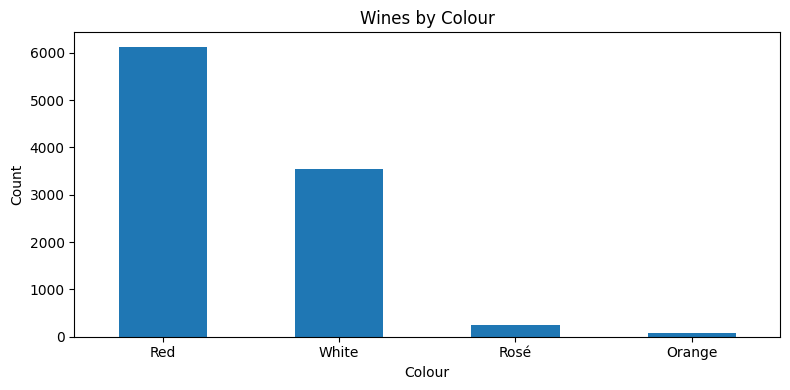

In [6]:
df["Colour"].value_counts().plot(kind="bar", figsize=(8, 4), title="Wines by Colour")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [7]:
df["Colour"].value_counts()

Colour
Red       6127
White     3541
Rosé       241
Orange      72
Name: count, dtype: int64

## Country & Region Distribution

France, USA, and Italy account for the majority of reviews. This reflects Decanter's editorial focus rather than global wine production. The long tail of smaller countries is still useful for semantic search — rare appellations can still be matched by flavour profile.

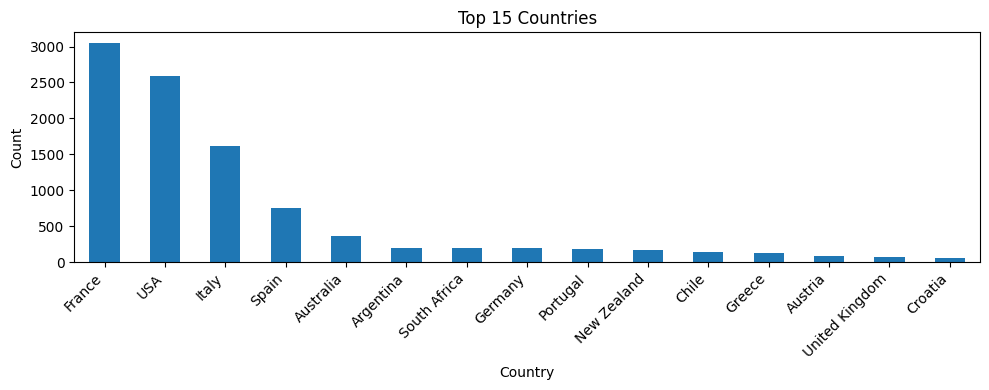

In [8]:
df["Country"].value_counts().head(15).plot(
    kind="bar", figsize=(10, 4), title="Top 15 Countries"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
df["Country"].value_counts().head(10)

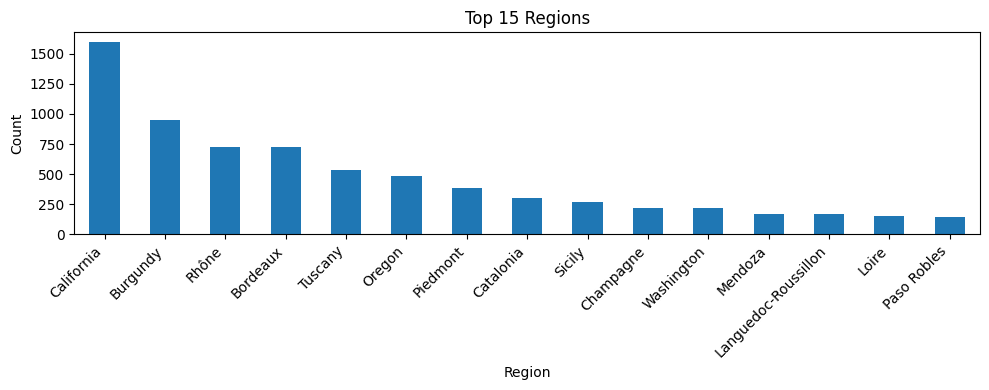

In [9]:
df["Region"].value_counts().head(15).plot(
    kind="bar", figsize=(10, 4), title="Top 15 Regions"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Score Distribution

Decanter scores cluster between 88–95 — typical for a publication that selects wines worth reviewing. Scores below 50 are data errors (likely scraper artefacts) and are dropped in preprocessing.

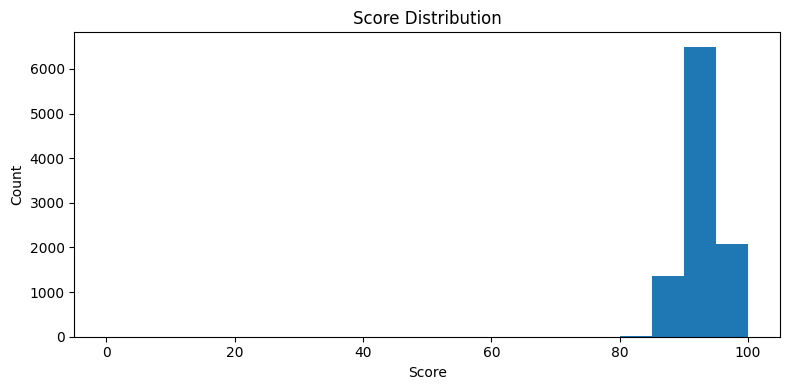

In [10]:
df["score"].dropna().plot(
    kind="hist", bins=20, figsize=(8, 4), title="Score Distribution"
)
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
df["score"].value_counts().head(20)

score
93.0     1629
92.0     1501
94.0     1447
91.0     1021
95.0      987
90.0      897
89.0      613
96.0      568
88.0      416
97.0      303
87.0      216
98.0      144
86.0       88
99.0       47
85.0       31
100.0      28
84.0        6
82.0        1
16.0        1
17.0        1
Name: count, dtype: int64

In [12]:
# Scores below 50 are scraper artefacts — dropped in preprocessing
df[df["score"] < 50][["title", "score", "description"]]

,title,score,description
4243,"Bruno Paillard, Première Cuvée, Champagne, France",16.0,<p>Hedgerow and gentle summer fruits. The pala...
5281,"Col d'Orcia, Brunello di Montalcino, Tuscany, ...",17.0,Clean and reserved exhibiting slow cooked red ...
6261,"Michele Chiarlo, Barolo Cerequio, Barolo / La ...",0.0,"Subtly aromatic potpourri nose with violets, d..."


## Description Length

`description` is the only field used for embeddings. We check length distribution to set a minimum threshold — very short descriptions (<50 chars) don't carry enough semantic signal and are filtered out in preprocessing.

In [13]:
df["desc_length"] = df["description"].dropna().apply(len)

df["desc_length"].describe()

count    9978.000000
mean      411.758669
std       208.315226
min        63.000000
25%       267.000000
50%       383.000000
75%       502.000000
max      3401.000000
Name: desc_length, dtype: float64

In [14]:
print("=== Shortest ===")
print(df.nsmallest(3, "desc_length")[["title", "desc_length", "description"]].to_string())

print("\n=== Longest ===")
print(df.nlargest(3, "desc_length")[["title", "desc_length", "description"]].to_string())

=== Shortest ===
                                                    title  desc_length                                                                 description
2444  Bratanov, Shishmanovo Vineyards Mavrud, Sakar, 2024         63.0             Lifted aromas of dark berry, cocoa and oak. Smoky and delicate.
3611  Mil Suelos, Zaha Cabernet Franc, Uco Valley, Paraje         67.0         Youthful, simple and shows signs of reduction, so must be decanted.
2420        Tikveš, Barovo, Tikves, North Macedonia, 2019         74.0  Cherry, cedar and leather, lively freshness with instant appeal. Generous.

=== Longest ===
                                                          title  desc_length                                                                                                                                                                                                                                                                                                              

In [15]:
pd.set_option("display.max_colwidth", None)
df.nlargest(3, "desc_length")[["title", "desc_length", "url"]]

,title,desc_length,url
3377,"Donelan, Obsidian Estate, Syrah, Sonoma County, Knights",3401.0,https://www.decanter.com/wine-reviews/usa/california/donelan-obsidian-estate-syrah-sonoma-county-knights-105289
9608,"Lokoya, Cabernet Sauvignon, Napa Valley, Diamond Mountain",2399.0,https://www.decanter.com/wine-reviews/usa/california/lokoya-cabernet-sauvignon-napa-valley-diamond-mountain-99269
9609,"Lokoya, Cabernet Sauvignon, Napa Valley, Spring Mountain",2369.0,https://www.decanter.com/wine-reviews/usa/california/lokoya-cabernet-sauvignon-napa-valley-spring-mountain-99270


## Grape Varieties

Cabernet Sauvignon, Chardonnay, and Pinot Noir dominate — reflecting both Decanter's coverage and global planting patterns. Blends (multiple varieties) are treated as unknown in grape-based evaluation metrics.

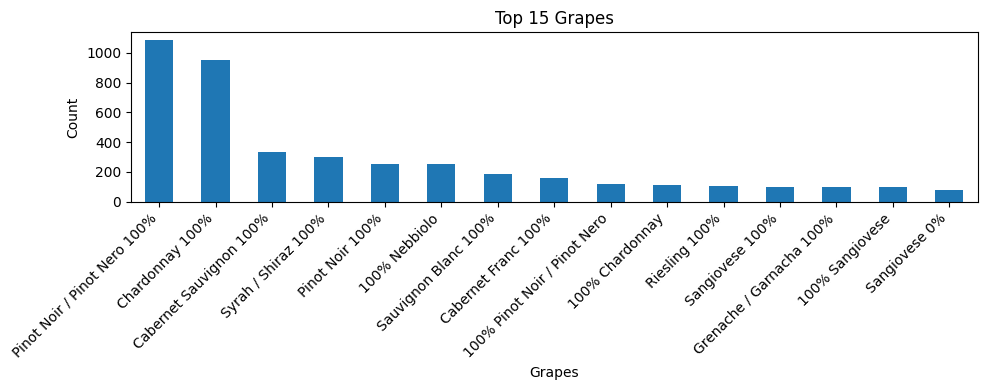

In [16]:
df["Grapes"].value_counts().head(15).plot(
    kind="bar", figsize=(10, 4), title="Top 15 Grapes"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Duplicates

Some wines appear multiple times — same description, different titles. This happens when Decanter publishes the same tasting note under both a producer name and a brand name. These are deduplicated in preprocessing by description hash.

In [17]:
print("Duplicate URLs:", df["url"].duplicated().sum())
print("Duplicate titles:", df["title"].duplicated().sum())
print("Duplicate descriptions:", df["description"].duplicated().sum())

Duplicate URLs: 0
Duplicate titles: 204
Duplicate descriptions: 9


In [18]:
mask = df["description"].duplicated(keep=False)
df[mask].sort_values("description")[["title", "description"]].head(10)

,title,description
5974,"Terra Nera, Andraemo, Maremma Toscana, Tuscany, Italy, 2022","Ripe red and black fruit with sour cherry and spice. Juicy palate marked by firm, rustic tannins, bright acidity and structure, finishing long and food-friendly."
5994,"LaSelva, Satus Ciliegiolo, Maremma Toscana, Tuscany, 2022","Ripe red and black fruit with sour cherry and spice. Juicy palate marked by firm, rustic tannins, bright acidity and structure, finishing long and food-friendly."
9112,"Evening Land, Summum Pinot Noir, Willamette Valley","The 2023 Summum comes from the oldest own-rooted block of Pinot Noir at Seven Springs, now an Eola-Amity Hills icon, which is dry-farmed. This vineyard was originally planted in 1982 with Pommard clone Pinot—rich, forest-borne aromatics, including sous bois and deep violet tones, and dusty Oregon blackberries. The palate is wonderfully layered and silken, with red and black berry fruits, and there are rich notes of turned earth, and wonderfully wild flavours of dried herbs and lavender."
9349,"Evening Land, Summum Pinot Noir, Willamette Valley","The 2023 Summum comes from the oldest own-rooted block of Pinot Noir at Seven Springs, now an Eola-Amity Hills icon, which is dry-farmed. This vineyard was originally planted in 1982 with Pommard clone Pinot—rich, forest-borne aromatics, including sous bois and deep violet tones, and dusty Oregon blackberries. The palate is wonderfully layered and silken, with red and black berry fruits, and there are rich notes of turned earth, and wonderfully wild flavours of dried herbs and lavender."
3473,"Merryvale, Cabernet Franc, Napa Valley, California, 2022","The Cabernet Franc is sourced from Stanton Vineyard in St Helena. Fermented for approximately 15 days on the skins and aged for 20 months in 50% new French oak, the wine showcases both the depth of the site and the varietal’s natural precision. In 2022, a small portion of Coombsville Cabernet Sauvignon was blended in. Aromatically, it opens with bright white pepper and tobacco leaf notes layered over rich cassis fruit, with hints of mulberry spice. While the wine carries the warmth and gentle tannin profile of the vintage, it remains well balanced and savoury, underpinned by a slate-stone minerality that brings lift and freshness. A very lovely, expressive take on Cabernet Franc in what was a challenging vintage."
3991,"Merryvale, Merryvale Cabernet Franc, Napa Valley, 2022","The Cabernet Franc is sourced from Stanton Vineyard in St Helena. Fermented for approximately 15 days on the skins and aged for 20 months in 50% new French oak, the wine showcases both the depth of the site and the varietal’s natural precision. In 2022, a small portion of Coombsville Cabernet Sauvignon was blended in. Aromatically, it opens with bright white pepper and tobacco leaf notes layered over rich cassis fruit, with hints of mulberry spice. While the wine carries the warmth and gentle tannin profile of the vintage, it remains well balanced and savoury, underpinned by a slate-stone minerality that brings lift and freshness. A very lovely, expressive take on Cabernet Franc in what was a challenging vintage."
3470,"Merryvale, Reserve Cabernet Sauvignon, Napa Valley, 2022","The Reserve Cabernet Sauvignon comes mostly from the 10-hectare Profile Estate Vineyard, a site of notable complexity with peaks of volcanic ash and lower areas of sandy loam, supplemented by a few barrels from additional sites. The 2022 Reserve is full-bodied, with savoury aromas of blackberry, white pepper, black truffle, charcuterie and leather, alongside loamy earth and violets. The tannins are supple and balanced, building with a bright saline-acid tension. The wines are made by Jeff Crawford together with consulting winemaker Jean Hoefliger."
3988,"Merryvale, Merryvale Reserve Cabernet Sauvignon, Napa","The Reserve Cabernet Sauvignon comes mostly from the 10-hectare Profile Estate Vineyard, a site of notable complexity with peaks of volcanic ash and lower area